In [1]:
import os
import json
import cv2
import numpy as np

DATA_PATH = "Data/Hurricane"
IMG_SIZE = 224

X_cnn = []
y_cnn = []
sample_frame_names = []
mask_areas = []

for json_file in os.listdir(f"{DATA_PATH}/JSON"):
    
    with open(f"{DATA_PATH}/JSON/{json_file}") as f:
        data = json.load(f)

    frame_path = os.path.join(DATA_PATH, data["Frame_Name"])
    image = cv2.imread(frame_path)

    if image is None:
        print("Could not read image:", frame_path)
        continue

    # OpenCV loads as BGR, convert to RGB
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    image = cv2.resize(image, (IMG_SIZE, IMG_SIZE))
    image = image / 255.0

    for building in data["Buildings"]:
        
        mask_filename = building[2]
        label = building[3]

        mask_path = os.path.join(DATA_PATH, "MASK", mask_filename)

        if not os.path.exists(mask_path):
            continue

        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

        if mask is None:
            print("Could not read mask:", mask_path)
            continue

        mask = cv2.resize(mask, (IMG_SIZE, IMG_SIZE))
        mask = mask / 255.0
        mask = np.expand_dims(mask, axis=-1)

        # Combine RGB image + mask channel
        combined = np.concatenate([image, mask], axis=-1)

        X_cnn.append(combined)
        y_cnn.append(label)
        sample_frame_names.append(data["Frame_Name"])
        mask_areas.append(float(np.mean(mask)))

X_cnn = np.array(X_cnn, dtype=np.float32)
y_cnn = np.array(y_cnn, dtype=np.int64)
sample_frame_names = np.array(sample_frame_names, dtype=str)
mask_areas = np.array(mask_areas, dtype=np.float32)

print("X_cnn shape:", X_cnn.shape)
print("y_cnn shape:", y_cnn.shape)
print("Labels:", sorted(set(y_cnn)))
print("Frames loaded:", len(np.unique(sample_frame_names)))
print("Mask samples:", mask_areas.shape[0])


X_cnn shape: (1458, 224, 224, 4)
y_cnn shape: (1458,)
Labels: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]
Frames loaded: 271
Mask samples: 1458


In [2]:
# Exploratory Data Analysis
#
# This section summarizes the hurricane dataset, inspects class balance,
# examines mask coverage, and shows representative image samples before
# training the CNN.


Dataset overview
----------------
Total samples: 1458
Unique labels: 6
Unique frames: 271

Label counts:
label
0    168
1    264
2    196
3    464
4    258
5    108
Name: count, dtype: int64

Average mask area fraction: 0.0214
Median mask area fraction: 0.0131
Min mask area fraction: 0.0013
Max mask area fraction: 0.3065


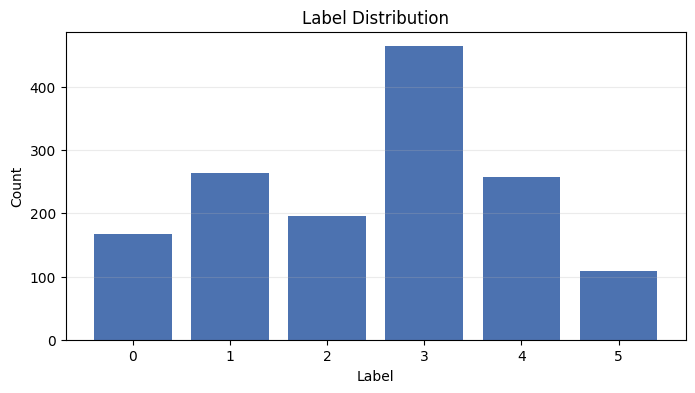

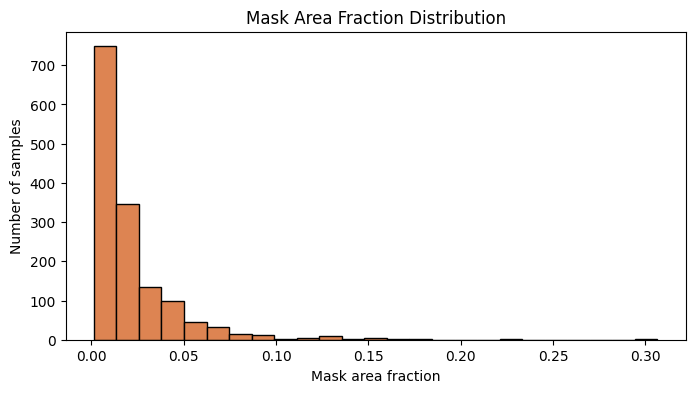

/var/folders/cy/ldh5cbmx3dq0q4qtcz88gdmw0000gn/T/ipykernel_27280/342059322.py:46: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(box_data, labels=[str(lbl) for lbl in labels_sorted], patch_artist=True,


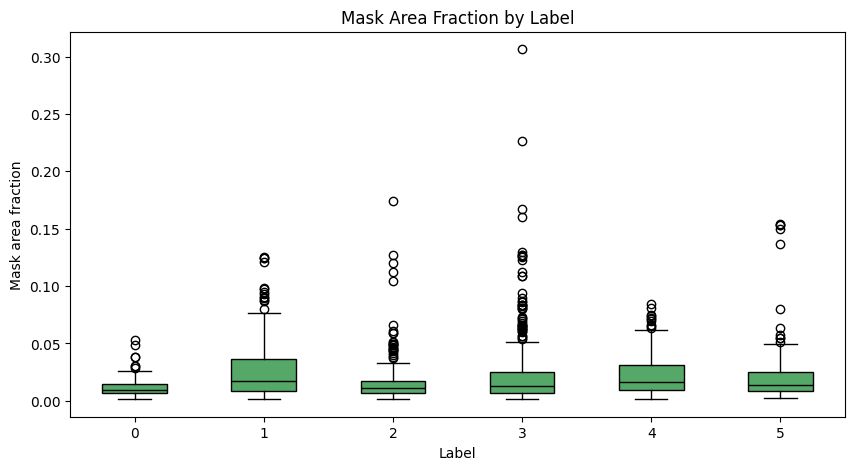

RGB channel means: [0.2293 0.2293 0.2293]
RGB channel stds: [0.2642 0.2987 0.303 ]
Mask channel mean: 0.0214
Mask channel std: 0.1440


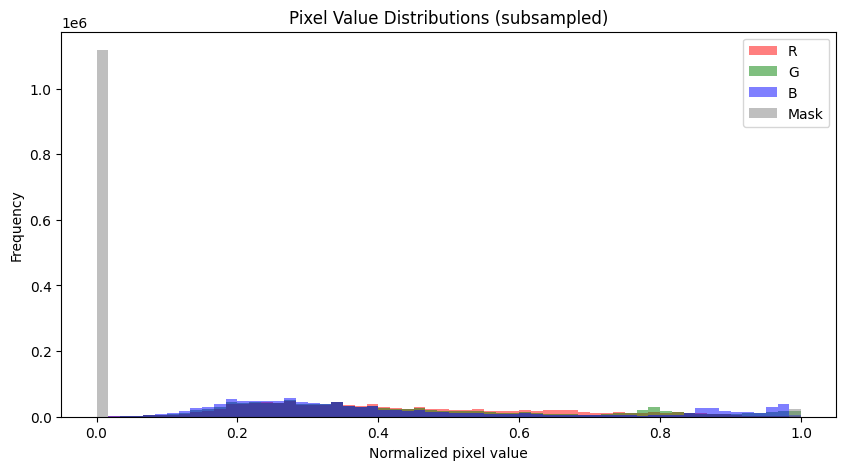

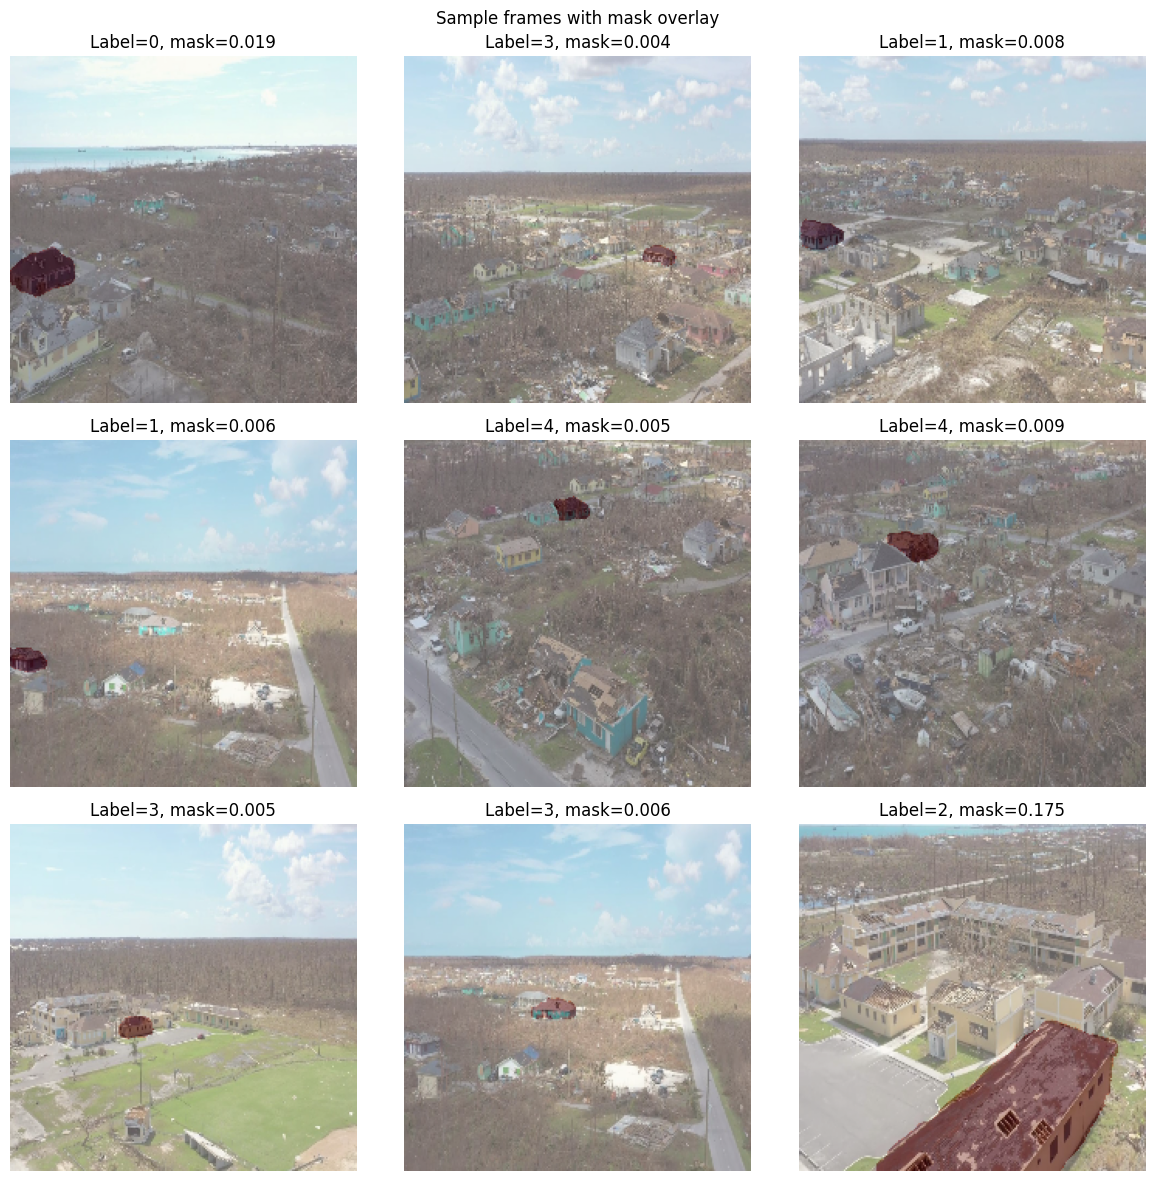

Majority label baseline: 3 accuracy = 0.318


In [3]:
import pandas as pd
import matplotlib.pyplot as plt

# Build a small data summary table for the CNN dataset
eda_df = pd.DataFrame({
    "label": y_cnn,
    "frame_name": sample_frame_names,
    "mask_area_fraction": mask_areas
})

print("Dataset overview")
print("----------------")
print(f"Total samples: {len(eda_df)}")
print(f"Unique labels: {eda_df['label'].nunique()}")
print(f"Unique frames: {eda_df['frame_name'].nunique()}")
print("")
print("Label counts:")
print(eda_df["label"].value_counts().sort_index())
print("")
print(f"Average mask area fraction: {eda_df['mask_area_fraction'].mean():.4f}")
print(f"Median mask area fraction: {eda_df['mask_area_fraction'].median():.4f}")
print(f"Min mask area fraction: {eda_df['mask_area_fraction'].min():.4f}")
print(f"Max mask area fraction: {eda_df['mask_area_fraction'].max():.4f}")

# Plot label distribution
label_counts = eda_df["label"].value_counts().sort_index()
plt.figure(figsize=(8, 4))
plt.bar(label_counts.index.astype(str), label_counts.values, color="#4C72B0")
plt.title("Label Distribution")
plt.xlabel("Label")
plt.ylabel("Count")
plt.grid(axis="y", alpha=0.25)
plt.show()

# Plot mask area distribution
plt.figure(figsize=(8, 4))
plt.hist(eda_df["mask_area_fraction"], bins=25, color="#DD8452", edgecolor="black")
plt.title("Mask Area Fraction Distribution")
plt.xlabel("Mask area fraction")
plt.ylabel("Number of samples")
plt.show()

plt.figure(figsize=(10, 5))
labels_sorted = sorted(eda_df["label"].unique())
box_data = [eda_df.loc[eda_df["label"] == lbl, "mask_area_fraction"].values for lbl in labels_sorted]
plt.boxplot(box_data, labels=[str(lbl) for lbl in labels_sorted], patch_artist=True,
            boxprops={"facecolor": "#55A868"}, medianprops={"color": "black"})
plt.title("Mask Area Fraction by Label")
plt.xlabel("Label")
plt.ylabel("Mask area fraction")
plt.show()

# Channel statistics for the CNN input tensors
rgb_mean = X_cnn[..., :3].mean(axis=(0, 1, 2))
rgb_std = X_cnn[..., :3].std(axis=(0, 1, 2))
mask_mean = X_cnn[..., 3].mean()
mask_std = X_cnn[..., 3].std()

print("RGB channel means:", np.round(rgb_mean, 4))
print("RGB channel stds:", np.round(rgb_std, 4))
print(f"Mask channel mean: {mask_mean:.4f}")
print(f"Mask channel std: {mask_std:.4f}")

# Plot pixel-value distributions for a subsample of pixels
pixel_sample = X_cnn[:, ::8, ::8, :].reshape(-1, 4)
plt.figure(figsize=(10, 5))
plt.hist(pixel_sample[:, 0], bins=60, alpha=0.5, label="R", color="red")
plt.hist(pixel_sample[:, 1], bins=60, alpha=0.5, label="G", color="green")
plt.hist(pixel_sample[:, 2], bins=60, alpha=0.5, label="B", color="blue")
plt.hist(pixel_sample[:, 3], bins=60, alpha=0.5, label="Mask", color="gray")
plt.title("Pixel Value Distributions (subsampled)")
plt.xlabel("Normalized pixel value")
plt.ylabel("Frequency")
plt.legend()
plt.show()

# Show sample image examples with mask overlay
sample_indices = np.random.choice(len(X_cnn), size=min(9, len(X_cnn)), replace=False)
fig, axes = plt.subplots(3, 3, figsize=(12, 12))
for ax, idx in zip(axes.flatten(), sample_indices):
    sample = X_cnn[idx]
    rgb = sample[..., :3]
    mask = sample[..., 3]
    ax.imshow(rgb)
    ax.imshow(mask, cmap="Reds", alpha=0.35)
    ax.set_title(f"Label={y_cnn[idx]}, mask={eda_df.loc[idx, 'mask_area_fraction']:.3f}")
    ax.axis("off")
plt.suptitle("Sample frames with mask overlay")
plt.tight_layout()
plt.show()

majority_label = eda_df["label"].mode().iloc[0]
majority_acc = np.mean(eda_df["label"] == majority_label)
print(f"Majority label baseline: {majority_label} accuracy = {majority_acc:.3f}")


In [4]:
from sklearn.model_selection import train_test_split

X_train_cnn, X_test_cnn, y_train_cnn, y_test_cnn = train_test_split(
    X_cnn,
    y_cnn,
    test_size=0.2,
    random_state=42,
    stratify=y_cnn
)

print("X_train_cnn:", X_train_cnn.shape)
print("X_test_cnn:", X_test_cnn.shape)
print("y_train_cnn:", y_train_cnn.shape)
print("y_test_cnn:", y_test_cnn.shape)

X_train_cnn: (1166, 224, 224, 4)
X_test_cnn: (292, 224, 224, 4)
y_train_cnn: (1166,)
y_test_cnn: (292,)


Train/Test label counts
   train  test
0    134    34
1    211    53
2    157    39
3    371    93
4    206    52
5     87    21


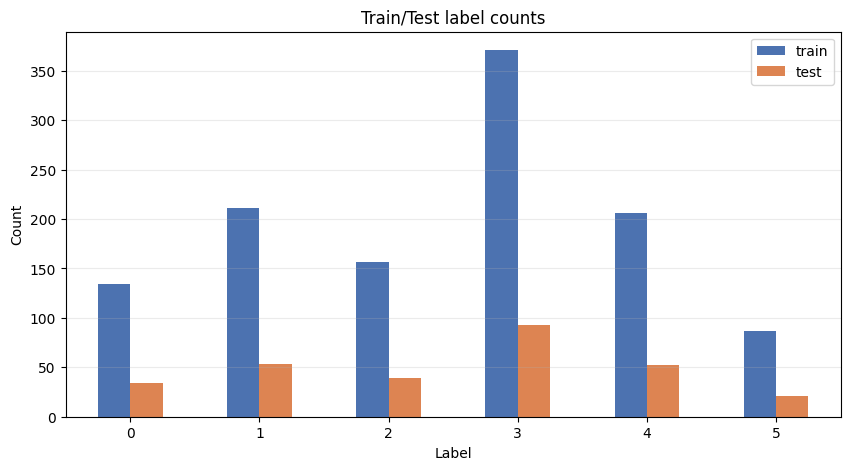

In [5]:
from collections import Counter
import pandas as pd

split_counts = pd.DataFrame(
    {
        "train": pd.Series(Counter(y_train_cnn)),
        "test": pd.Series(Counter(y_test_cnn))
    }
).fillna(0).astype(int)

print("Train/Test label counts")
print(split_counts)

split_counts.plot(kind="bar", figsize=(10, 5), color=["#4C72B0", "#DD8452"])
plt.title("Train/Test label counts")
plt.xlabel("Label")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.25)
plt.show()


In [6]:
from sklearn.utils.class_weight import compute_class_weight

classes = np.unique(y_train_cnn)

class_weights_array = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train_cnn
)

class_weights = {
    int(cls): float(weight)
    for cls, weight in zip(classes, class_weights_array)
}

print(class_weights)

{0: 1.4502487562189055, 1: 0.9210110584518167, 2: 1.237791932059448, 3: 0.5238095238095238, 4: 0.9433656957928802, 5: 2.2337164750957856}


In [7]:
import tensorflow as tf
from tensorflow.keras import layers, models

num_classes = len(np.unique(y_cnn))

cnn = models.Sequential([
    layers.Input(shape=(224, 224, 4)),

    layers.Conv2D(32, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),

    layers.Dense(256, activation="relu"),
    layers.Dropout(0.5),

    layers.Dense(128, activation="relu"),
    layers.Dropout(0.3),

    layers.Dense(num_classes, activation="softmax")
])

cnn.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

cnn.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │         1,184 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 24, 24, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 18432)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     4,718,848 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,993,638 (19.05 MB)

 Trainable params: 4,993,638 (19.05 MB)

 Non-trainable params: 0 (0.00 B)

Training/validation label counts
   train  val
0    107   27
1    169   42
2    125   32
3    297   74
4    165   41
5     69   18


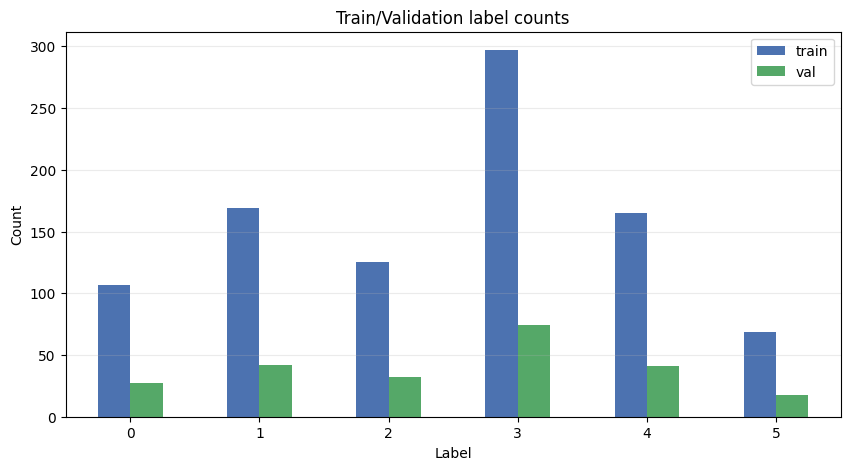

Epoch 1/30
59/59 ━━━━━━━━━━━━━━━━━━━━ 10s 158ms/step - accuracy: 0.2382 - loss: 1.7961 - val_accuracy: 0.3333 - val_loss: 1.7197
Epoch 2/30
59/59 ━━━━━━━━━━━━━━━━━━━━ 8s 144ms/step - accuracy: 0.3047 - loss: 1.7704 - val_accuracy: 0.2991 - val_loss: 1.6529
Epoch 3/30
59/59 ━━━━━━━━━━━━━━━━━━━━ 9s 147ms/step - accuracy: 0.3187 - loss: 1.7335 - val_accuracy: 0.2821 - val_loss: 1.7217
Epoch 4/30
59/59 ━━━━━━━━━━━━━━━━━━━━ 9s 146ms/step - accuracy: 0.3584 - loss: 1.6291 - val_accuracy: 0.3547 - val_loss: 1.6086
Epoch 5/30
59/59 ━━━━━━━━━━━━━━━━━━━━ 9s 145ms/step - accuracy: 0.4528 - loss: 1.4496 - val_accuracy: 0.3932 - val_loss: 1.6207
Epoch 6/30
59/59 ━━━━━━━━━━━━━━━━━━━━ 9s 145ms/step - accuracy: 0.5054 - loss: 1.2766 - val_accuracy: 0.3889 - val_loss: 1.5687
Epoch 7/30
59/59 ━━━━━━━━━━━━━━━━━━━━ 9s 148ms/step - accuracy: 0.5762 - loss: 1.1201 - val_accuracy: 0.4359 - val_loss: 1.6091
Epoch 8/30
59/59 ━━━━━━━━━━━━━━━━━━━━ 9s 147ms/step - accuracy: 0.5976 - loss: 1.0039 - val_accuracy: 0

In [8]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

from collections import Counter

X_train_cnn, X_val_cnn, y_train_cnn, y_val_cnn = train_test_split(
    X_train_cnn,
    y_train_cnn,
    test_size=0.2,
    random_state=42,
    stratify=y_train_cnn
)

print("Training/validation label counts")
train_val_counts = pd.DataFrame(
    {
        "train": pd.Series(Counter(y_train_cnn)),
        "val": pd.Series(Counter(y_val_cnn))
    }
).fillna(0).astype(int)
print(train_val_counts)
train_val_counts.plot(kind="bar", figsize=(10, 5), color=["#4C72B0", "#55A868"])
plt.title("Train/Validation label counts")
plt.xlabel("Label")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.25)
plt.show()

history = cnn.fit(
    X_train_cnn,
    y_train_cnn,
    validation_data=(X_val_cnn, y_val_cnn),
    epochs=30,
    batch_size=16,
    class_weight=class_weights,
    callbacks=[early_stop],
    verbose=1
)


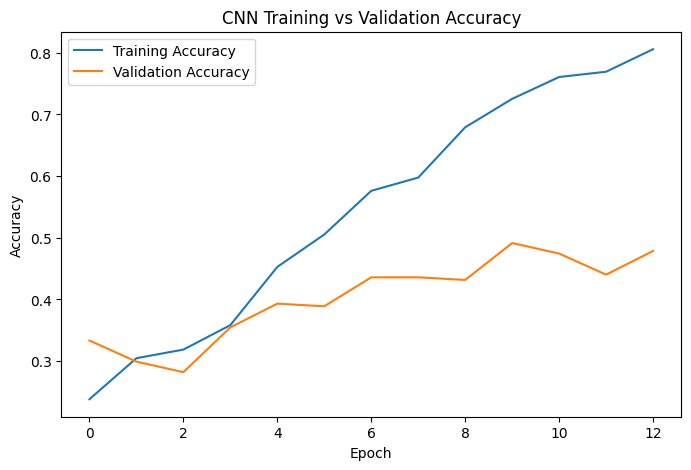

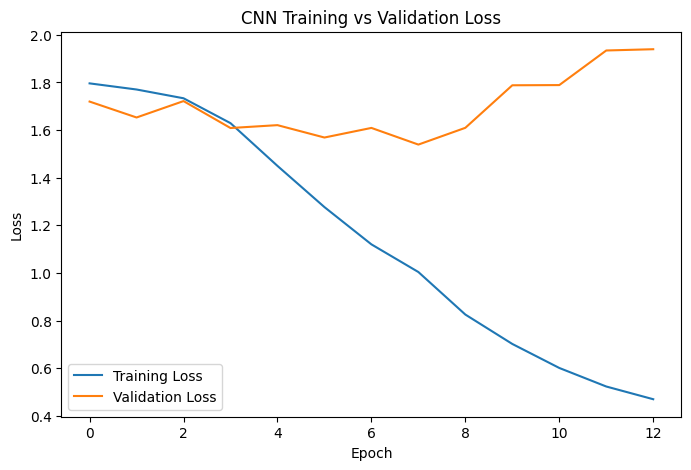

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("CNN Training vs Validation Accuracy")
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("CNN Training vs Validation Loss")
plt.legend()
plt.show()

In [10]:
test_loss, test_acc = cnn.evaluate(X_test_cnn, y_test_cnn, verbose=0)

print("CNN Test Loss:", test_loss)
print("CNN Test Accuracy:", test_acc)

CNN Test Loss: 1.4498162269592285
CNN Test Accuracy: 0.4931506812572479


10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 74ms/step
              precision    recall  f1-score   support

           0       0.27      0.38      0.32        34
           1       0.60      0.57      0.58        53
           2       0.42      0.38      0.40        39
           3       0.60      0.53      0.56        93
           4       0.55      0.46      0.50        52
           5       0.39      0.62      0.48        21

    accuracy                           0.49       292
   macro avg       0.47      0.49      0.47       292
weighted avg       0.51      0.49      0.50       292



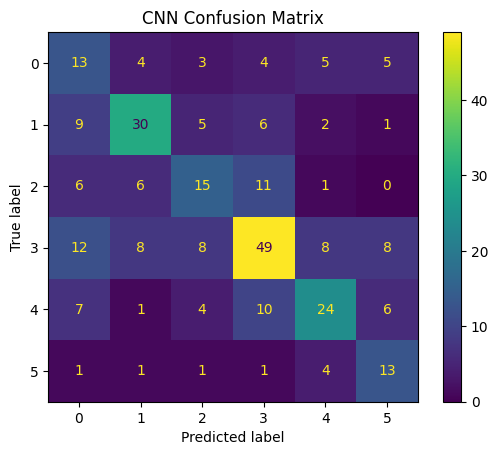

In [11]:
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
import numpy as np
import matplotlib.pyplot as plt

y_pred_probs = cnn.predict(X_test_cnn)
y_pred_cnn = np.argmax(y_pred_probs, axis=1)

print(classification_report(y_test_cnn, y_pred_cnn))

ConfusionMatrixDisplay.from_predictions(y_test_cnn, y_pred_cnn)
plt.title("CNN Confusion Matrix")
plt.show()

In [12]:
def within_one_accuracy(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    return np.mean(np.abs(y_true - y_pred) <= 1)

cnn_pm1_acc = within_one_accuracy(y_test_cnn, y_pred_cnn)

print("CNN Strict Accuracy:", test_acc)
print("CNN ±1 Class Accuracy:", cnn_pm1_acc)

CNN Strict Accuracy: 0.4931506812572479
CNN ±1 Class Accuracy: 0.7363013698630136


In [13]:
import pandas as pd

cnn_results = pd.DataFrame([
    {
        "Model": "CNN",
        "Strict Accuracy": test_acc,
        "±1 Class Accuracy": cnn_pm1_acc,
        "Test Loss": test_loss
    }
])

cnn_results

,Model,Strict Accuracy,±1 Class Accuracy,Test Loss
0,CNN,0.493151,0.736301,1.449816


In [14]:

num_classes = len(np.unique(y_cnn))

cnn_small = models.Sequential([
    layers.Input(shape=(224, 224, 4)),

    # Data augmentation
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.10),

    layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation="relu", padding="same"),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation="relu", padding="same"),
    layers.BatchNormalization(),

    layers.GlobalAveragePooling2D(),

    layers.Dense(128, activation="relu"),
    layers.Dropout(0.5),

    layers.Dense(num_classes, activation="softmax")
])

cnn_small.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0003),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

cnn_small.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip (RandomFlip)        │ (None, 224, 224, 4)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation                 │ (None, 224, 224, 4)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom (RandomZoom)        │ (None, 224, 224, 4)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 224, 224, 32)   │         1,184 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 28, 28, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 28, 28, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 259,814 (1014.90 KB)

 Trainable params: 259,110 (1012.15 KB)

 Non-trainable params: 704 (2.75 KB)

In [15]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=6,
    restore_best_weights=True
)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=3,
    min_lr=1e-6
)

history_small = cnn_small.fit(
    X_train_cnn,
    y_train_cnn,
    validation_data=(X_val_cnn, y_val_cnn),
    epochs=40,
    batch_size=16,
    class_weight=class_weights,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

Epoch 1/40
59/59 ━━━━━━━━━━━━━━━━━━━━ 17s 263ms/step - accuracy: 0.1717 - loss: 1.8218 - val_accuracy: 0.1154 - val_loss: 1.9249 - learning_rate: 3.0000e-04
Epoch 2/40
59/59 ━━━━━━━━━━━━━━━━━━━━ 16s 266ms/step - accuracy: 0.2242 - loss: 1.7414 - val_accuracy: 0.1154 - val_loss: 2.0274 - learning_rate: 3.0000e-04
Epoch 3/40
59/59 ━━━━━━━━━━━━━━━━━━━━ 15s 252ms/step - accuracy: 0.2146 - loss: 1.7509 - val_accuracy: 0.1154 - val_loss: 2.1551 - learning_rate: 3.0000e-04
Epoch 4/40
59/59 ━━━━━━━━━━━━━━━━━━━━ 15s 250ms/step - accuracy: 0.2114 - loss: 1.7147 - val_accuracy: 0.1453 - val_loss: 2.2047 - learning_rate: 3.0000e-04
Epoch 5/40
59/59 ━━━━━━━━━━━━━━━━━━━━ 15s 253ms/step - accuracy: 0.2135 - loss: 1.7186 - val_accuracy: 0.1581 - val_loss: 2.1923 - learning_rate: 1.5000e-04
Epoch 6/40
59/59 ━━━━━━━━━━━━━━━━━━━━ 15s 251ms/step - accuracy: 0.2532 - loss: 1.6689 - val_accuracy: 0.1624 - val_loss: 2.0409 - learning_rate: 1.5000e-04
Epoch 7/40
59/59 ━━━━━━━━━━━━━━━━━━━━ 15s 253ms/step - acc

10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 102ms/step
Improved CNN Test Loss: 1.9263602495193481
Improved CNN Test Accuracy: 0.1164383590221405
Improved CNN ±1 Class Accuracy: 0.2979452054794521
              precision    recall  f1-score   support

           0       0.12      1.00      0.21        34
           1       0.00      0.00      0.00        53
           2       0.00      0.00      0.00        39
           3       0.00      0.00      0.00        93
           4       0.00      0.00      0.00        52
           5       0.00      0.00      0.00        21

    accuracy                           0.12       292
   macro avg       0.02      0.17      0.03       292
weighted avg       0.01      0.12      0.02       292



/Users/luisromero/Desktop/Spring 2026/AI/FinalProject/AI-Final-Project-GroupRRM/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/luisromero/Desktop/Spring 2026/AI/FinalProject/AI-Final-Project-GroupRRM/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/luisromero/Desktop/Spring 2026/AI/FinalProject/AI-Final-Project-GroupRRM/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and

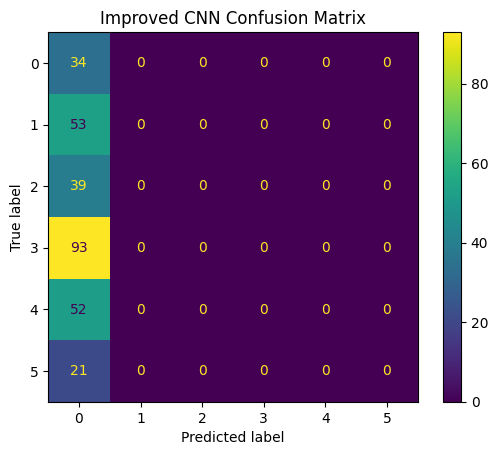

In [16]:
test_loss_small, test_acc_small = cnn_small.evaluate(X_test_cnn, y_test_cnn, verbose=0)

y_pred_probs_small = cnn_small.predict(X_test_cnn)
y_pred_small = np.argmax(y_pred_probs_small, axis=1)

pm1_acc_small = within_one_accuracy(y_test_cnn, y_pred_small)

print("Improved CNN Test Loss:", test_loss_small)
print("Improved CNN Test Accuracy:", test_acc_small)
print("Improved CNN ±1 Class Accuracy:", pm1_acc_small)

print(classification_report(y_test_cnn, y_pred_small))

ConfusionMatrixDisplay.from_predictions(y_test_cnn, y_pred_small)
plt.title("Improved CNN Confusion Matrix")
plt.show()

In [17]:
### The second CNN architecture with batch normalization and global average pooling performed worse than the original CNN. 
### It collapsed into predicting mostly one class, so it was not selected as the final model.


cnn_comparison = pd.DataFrame([
    {
        "Model": "Original CNN",
        "Strict Accuracy": test_acc,
        "±1 Class Accuracy": cnn_pm1_acc,
        "Test Loss": test_loss
    },
    {
        "Model": "Improved CNN",
        "Strict Accuracy": test_acc_small,
        "±1 Class Accuracy": pm1_acc_small,
        "Test Loss": test_loss_small
    }
])

cnn_comparison

,Model,Strict Accuracy,±1 Class Accuracy,Test Loss
0,Original CNN,0.493151,0.736301,1.449816
1,Improved CNN,0.116438,0.297945,1.926360


In [18]:
import numpy as np

num_classes = len(np.unique(y_cnn))

cnn_v2 = models.Sequential([
    layers.Input(shape=(224, 224, 4)),

    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.05),

    layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),

    layers.Dense(256, activation="relu"),
    layers.Dropout(0.6),

    layers.Dense(128, activation="relu"),
    layers.Dropout(0.4),

    layers.Dense(num_classes, activation="softmax")
])

cnn_v2.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0003),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

cnn_v2.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip_1 (RandomFlip)      │ (None, 224, 224, 4)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation_1               │ (None, 224, 224, 4)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom_1 (RandomZoom)      │ (None, 224, 224, 4)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 224, 224, 32)   │         1,184 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 28, 28, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 256)            │     6,422,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,697,574 (25.55 MB)

 Trainable params: 6,697,574 (25.55 MB)

 Non-trainable params: 0 (0.00 B)

In [19]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    min_lr=1e-6
)

history_v2 = cnn_v2.fit(
    X_train_cnn,
    y_train_cnn,
    validation_data=(X_val_cnn, y_val_cnn),
    epochs=40,
    batch_size=16,
    class_weight=class_weights,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

Epoch 1/40
59/59 ━━━━━━━━━━━━━━━━━━━━ 14s 209ms/step - accuracy: 0.1738 - loss: 1.8028 - val_accuracy: 0.1325 - val_loss: 1.7908 - learning_rate: 3.0000e-04
Epoch 2/40
59/59 ━━━━━━━━━━━━━━━━━━━━ 12s 205ms/step - accuracy: 0.1427 - loss: 1.7903 - val_accuracy: 0.0855 - val_loss: 1.7969 - learning_rate: 3.0000e-04
Epoch 3/40
59/59 ━━━━━━━━━━━━━━━━━━━━ 12s 200ms/step - accuracy: 0.1577 - loss: 1.7912 - val_accuracy: 0.1154 - val_loss: 1.7926 - learning_rate: 3.0000e-04
Epoch 4/40
59/59 ━━━━━━━━━━━━━━━━━━━━ 11s 191ms/step - accuracy: 0.1448 - loss: 1.7902 - val_accuracy: 0.1752 - val_loss: 1.7916 - learning_rate: 1.5000e-04
Epoch 5/40
59/59 ━━━━━━━━━━━━━━━━━━━━ 12s 196ms/step - accuracy: 0.1352 - loss: 1.7907 - val_accuracy: 0.1154 - val_loss: 1.7904 - learning_rate: 1.5000e-04
Epoch 6/40
59/59 ━━━━━━━━━━━━━━━━━━━━ 11s 192ms/step - accuracy: 0.1749 - loss: 1.7919 - val_accuracy: 0.2051 - val_loss: 1.7887 - learning_rate: 1.5000e-04
Epoch 7/40
59/59 ━━━━━━━━━━━━━━━━━━━━ 11s 192ms/step - acc

10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 108ms/step
CNN v2 Test Loss: 1.5478324890136719
CNN v2 Test Accuracy: 0.3732876777648926
CNN v2 ±1 Class Accuracy: 0.6267123287671232
              precision    recall  f1-score   support

           0       0.28      0.41      0.33        34
           1       0.38      0.40      0.39        53
           2       0.24      0.28      0.26        39
           3       0.60      0.29      0.39        93
           4       0.41      0.44      0.43        52
           5       0.33      0.62      0.43        21

    accuracy                           0.37       292
   macro avg       0.37      0.41      0.37       292
weighted avg       0.42      0.37      0.37       292



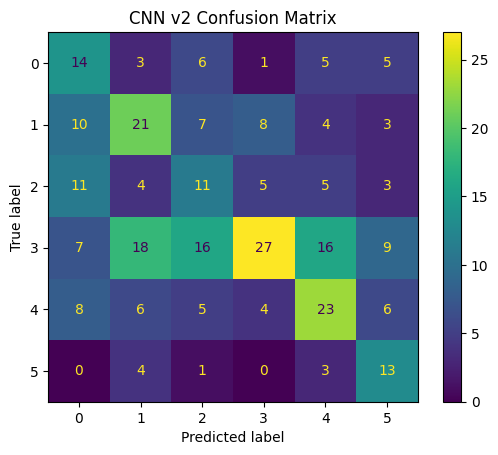

In [20]:
test_loss_v2, test_acc_v2 = cnn_v2.evaluate(X_test_cnn, y_test_cnn, verbose=0)

y_pred_probs_v2 = cnn_v2.predict(X_test_cnn)
y_pred_v2 = np.argmax(y_pred_probs_v2, axis=1)

pm1_acc_v2 = within_one_accuracy(y_test_cnn, y_pred_v2)

print("CNN v2 Test Loss:", test_loss_v2)
print("CNN v2 Test Accuracy:", test_acc_v2)
print("CNN v2 ±1 Class Accuracy:", pm1_acc_v2)

print(classification_report(y_test_cnn, y_pred_v2, zero_division=0))

ConfusionMatrixDisplay.from_predictions(y_test_cnn, y_pred_v2)
plt.title("CNN v2 Confusion Matrix")
plt.show()

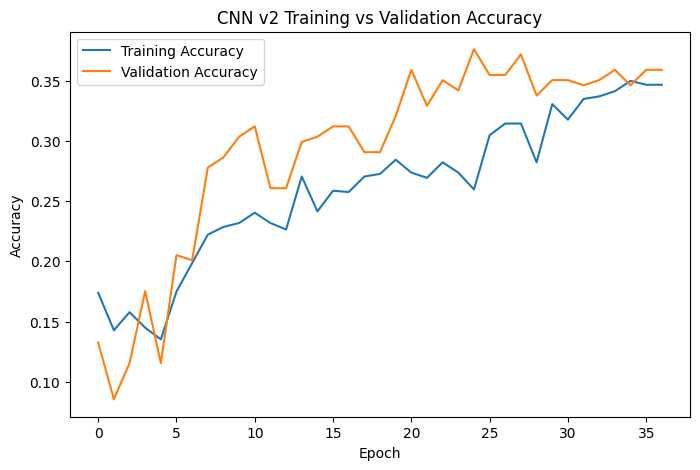

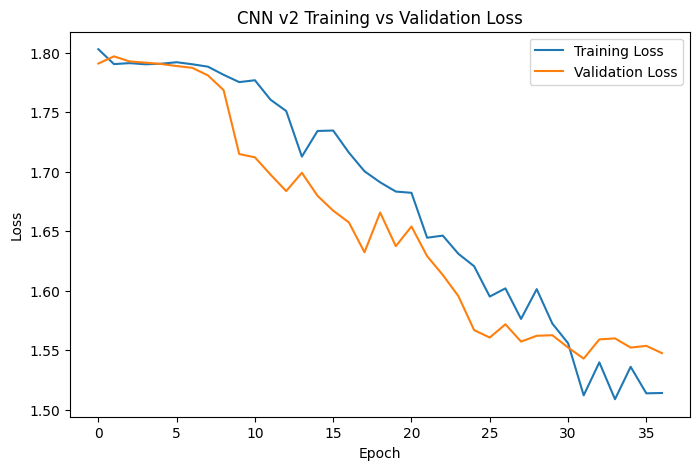

In [21]:
plt.figure(figsize=(8, 5))
plt.plot(history_v2.history["accuracy"], label="Training Accuracy")
plt.plot(history_v2.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("CNN v2 Training vs Validation Accuracy")
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history_v2.history["loss"], label="Training Loss")
plt.plot(history_v2.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("CNN v2 Training vs Validation Loss")
plt.legend()
plt.show()

In [22]:
cnn_comparison = pd.DataFrame([
    {
        "Model": "Original CNN",
        "Strict Accuracy": test_acc,
        "±1 Class Accuracy": cnn_pm1_acc,
        "Test Loss": test_loss
    },
    {
        "Model": "CNN v2",
        "Strict Accuracy": test_acc_v2,
        "±1 Class Accuracy": pm1_acc_v2,
        "Test Loss": test_loss_v2
    }
])

cnn_comparison

,Model,Strict Accuracy,±1 Class Accuracy,Test Loss
0,Original CNN,0.493151,0.736301,1.449816
1,CNN v2,0.373288,0.626712,1.547832


### Trying another CNN

In [23]:

num_classes = len(np.unique(y_cnn))

cnn_v3 = models.Sequential([
    layers.Input(shape=(224, 224, 4)),

    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.05),

    layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(256, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),

    layers.GlobalAveragePooling2D(),

    layers.Dense(128, activation="relu"),
    layers.Dropout(0.4),

    layers.Dense(num_classes, activation="softmax")
])

cnn_v3.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0003),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

cnn_v3.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip_2 (RandomFlip)      │ (None, 224, 224, 4)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation_2               │ (None, 224, 224, 4)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom_2 (RandomZoom)      │ (None, 224, 224, 4)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 224, 224, 32)   │         1,184 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 422,374 (1.61 MB)

 Trainable params: 422,374 (1.61 MB)

 Non-trainable params: 0 (0.00 B)

In [24]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=6,
    restore_best_weights=True
)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=3,
    min_lr=1e-6
)

history_v3 = cnn_v3.fit(
    X_train_cnn,
    y_train_cnn,
    validation_data=(X_val_cnn, y_val_cnn),
    epochs=50,
    batch_size=16,
    class_weight=class_weights,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

Epoch 1/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 16s 247ms/step - accuracy: 0.1695 - loss: 1.7964 - val_accuracy: 0.1752 - val_loss: 1.7901 - learning_rate: 3.0000e-04
Epoch 2/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 14s 244ms/step - accuracy: 0.1609 - loss: 1.7904 - val_accuracy: 0.2479 - val_loss: 1.7873 - learning_rate: 3.0000e-04
Epoch 3/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 13s 227ms/step - accuracy: 0.1803 - loss: 1.7896 - val_accuracy: 0.2821 - val_loss: 1.7824 - learning_rate: 3.0000e-04
Epoch 4/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 13s 226ms/step - accuracy: 0.1674 - loss: 1.7859 - val_accuracy: 0.1966 - val_loss: 1.7645 - learning_rate: 3.0000e-04
Epoch 5/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 14s 232ms/step - accuracy: 0.2071 - loss: 1.7812 - val_accuracy: 0.1581 - val_loss: 1.7786 - learning_rate: 3.0000e-04
Epoch 6/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 14s 229ms/step - accuracy: 0.1781 - loss: 1.7778 - val_accuracy: 0.2137 - val_loss: 1.7741 - learning_rate: 3.0000e-04
Epoch 7/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 13s 227ms/step - acc

10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 114ms/step
CNN v3 Test Loss: 1.7114685773849487
CNN v3 Test Accuracy: 0.21232876181602478
CNN v3 ±1 Class Accuracy: 0.4931506849315068
              precision    recall  f1-score   support

           0       0.19      0.68      0.30        34
           1       0.27      0.13      0.18        53
           2       0.05      0.03      0.03        39
           3       0.27      0.17      0.21        93
           4       0.22      0.29      0.25        52
           5       0.00      0.00      0.00        21

    accuracy                           0.21       292
   macro avg       0.17      0.22      0.16       292
weighted avg       0.20      0.21      0.18       292



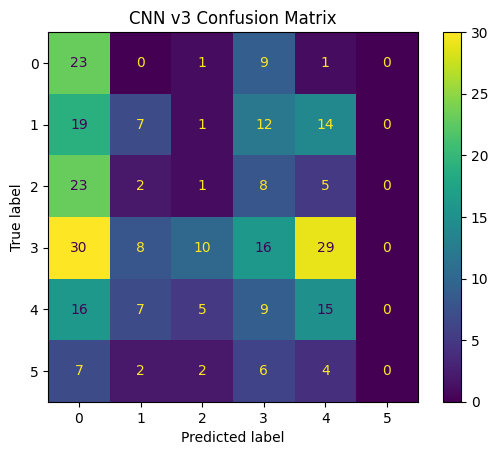

In [25]:
test_loss_v3, test_acc_v3 = cnn_v3.evaluate(X_test_cnn, y_test_cnn, verbose=0)

y_pred_probs_v3 = cnn_v3.predict(X_test_cnn)
y_pred_v3 = np.argmax(y_pred_probs_v3, axis=1)

pm1_acc_v3 = within_one_accuracy(y_test_cnn, y_pred_v3)

print("CNN v3 Test Loss:", test_loss_v3)
print("CNN v3 Test Accuracy:", test_acc_v3)
print("CNN v3 ±1 Class Accuracy:", pm1_acc_v3)

print(classification_report(y_test_cnn, y_pred_v3, zero_division=0))

ConfusionMatrixDisplay.from_predictions(y_test_cnn, y_pred_v3)
plt.title("CNN v3 Confusion Matrix")
plt.show()

In [26]:
cnn_comparison = pd.DataFrame([
    {
        "Model": "Original CNN",
        "Strict Accuracy": test_acc,
        "±1 Class Accuracy": cnn_pm1_acc,
        "Test Loss": test_loss
    },
    {
        "Model": "CNN v2",
        "Strict Accuracy": test_acc_v2,
        "±1 Class Accuracy": pm1_acc_v2,
        "Test Loss": test_loss_v2
    },
    {
        "Model": "CNN v3",
        "Strict Accuracy": test_acc_v3,
        "±1 Class Accuracy": pm1_acc_v3,
        "Test Loss": test_loss_v3
    }
])

cnn_comparison

,Model,Strict Accuracy,±1 Class Accuracy,Test Loss
0,Original CNN,0.493151,0.736301,1.449816
1,CNN v2,0.373288,0.626712,1.547832
2,CNN v3,0.212329,0.493151,1.711469


## CNN Model Comparison

Three CNN architectures were tested. The original CNN performed the best overall, achieving the highest strict accuracy, highest ±1 class accuracy, and lowest test loss. CNN v2 and CNN v3 were intended to reduce overfitting through augmentation, dropout, and architectural changes, but both performed worse on the test set.

Because the original CNN had the best overall performance, it was selected as the final neural network model.